# 2. PROJE ÖDEVİ - BLG-407 MAKİNE ÖĞRENMESİ

**Adınız:** Mustafa Erdem

**Soyadınız:** Kaya

**Okul Numaranız:** 2212721009

**GitHub Repo Bağlantısı:** `https://github.com/erdemkaya4332/YoloV8_Nesne_Tespiti`

---

## Proje Konusu: YOLOv8 ile Nesne Tespiti ve PyQt5 Tabanlı Görsel Arayüz Uygulaması

Bu projede, mutfak eşyalarını tespit etmek için YOLOv8 modeli eğitilecek ve PyQt5 kullanılarak görsel bir arayüz uygulaması geliştirilecektir.

### Proje Kapsamı:
1. **Veri Seti Hazırlığı**: Roboflow platformundan mutfak eşyaları veri seti indirilecek
2. **YOLOv8 Model Eğitimi**: Veri seti üzerinde YOLOv8 modeli eğitilecek
3. **Model Değerlendirme**: mAP, loss gibi başarı metrikleri raporlanacak
4. **PyQt5 GUI Geliştirme**: Görsel arayüz uygulaması oluşturulacak


# Adım 1: Gerekli Kütüphanelerin Kurulumu ve İçe Aktarılması

Bu bölümde, proje için gerekli kütüphaneler kurulacak ve içe aktarılacaktır.

## Kütüphaneler:

* **`ultralytics`**: YOLOv8 modelini eğitmek ve kullanmak için ana kütüphane
* **`roboflow`**: Roboflow platformundan veri seti indirmek için
* **`torch` (PyTorch)**: YOLOv8'in backend'i olarak kullanılır
* **`matplotlib`**: Eğitim grafiklerini görselleştirmek için
* **`numpy`**: Sayısal işlemler için
* **`cv2` (OpenCV)**: Görüntü işleme için
* **`PIL` (Pillow)**: Görüntü manipülasyonu için
* **`PyQt5`**: GUI uygulaması geliştirmek için (ayrı bir dosyada kullanılacak)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Gerekli kütüphanelerin kurulumu
%pip install ultralytics roboflow

from IPython import display
display.clear_output()
print("✅ Kütüphane kurulumu tamamlandı!")

# Kütüphanelerin içe aktarılması
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

print("✅ Tüm kütüphaneler başarıyla yüklendi!")


✅ Kütüphane kurulumu tamamlandı!
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Tüm kütüphaneler başarıyla yüklendi!


# Adım 2: Veri Setinin Hazırlanması ve İndirilmesi

Bu bölümde, Roboflow platformundan mutfak eşyaları veri seti indirilecektir.

## Veri Seti Özellikleri:

* **Kaynak**: Roboflow platformu (kendi oluşturduğumuz veri seti)
* **Sınıf Sayısı**: En az 2 farklı sınıf (mutfak eşyaları)
* **Toplam Görsel Sayısı**: 200+ etiketli görsel
* **Etiketleme Formatı**: YOLOv8 uyumlu (txt formatında)
* **Görsel Formatı**: JPG/PNG

## Roboflow API Kullanımı:

Roboflow API'si kullanılarak veri seti otomatik olarak indirilecek ve YOLOv8 formatına dönüştürülecektir.


In [8]:
api_key_path = "/content/drive/MyDrive/makine öğrenmesi/ödev2/API_Keys/roboflow_api_key.txt"

# API key dosyasını oku
try:
    with open(api_key_path, 'r', encoding='utf-8') as f: # Ensure utf-8 encoding to handle BOM
        api_key = f.read().strip().replace('\ufeff', '')  # Remove BOM character if present and strip whitespace

    if not api_key:
        raise ValueError("API key dosyası boş!")

    print("✅ API key Google Drive'dan başarıyla okundu!")
    print(f"📁 Dosya yolu: {api_key_path}")

except FileNotFoundError:
    print(f"❌ HATA: API key dosyası bulunamadı: {api_key_path}")
    print("\n📝 Yapmanız gerekenler:")
    print("1. Google Drive'ınızda 'API_Keys' klasörü oluşturun")
    print("2. O klasöre 'roboflow_api_key.txt' dosyası oluşturun")
    print("3. Dosyanın içine sadece API key'inizi yazın (başka bir şey olmadan)")
    print("4. Yukarıdaki 'api_key_path' değişkenini kendi klasör yolunuza göre güncelleyin")
    print("\n💡 Örnek yol: /content/drive/MyDrive/API_Keys/roboflow_api_key.txt")
    raise

except Exception as e:
    print(f"❌ HATA: API key okunurken bir sorun oluştu: {str(e)}")
    raise

✅ API key Google Drive'dan başarıyla okundu!
📁 Dosya yolu: /content/drive/MyDrive/makine öğrenmesi/ödev2/API_Keys/roboflow_api_key.txt


In [9]:
# Roboflow'dan veri setini indir
# API key ve workspace bilgileri ile veri setine erişim sağlanır

rf = Roboflow(api_key=api_key)
project = rf.workspace("erdem-5ubfq").project("mutfak-wvkhr")
version = project.version(2)
dataset = version.download("yolov8")

# Veri setinin indiği klasör yolunu al
dataset_path = dataset.location
print(f"\n📁 Veri seti yolu: {dataset_path}")
print(f"📊 Veri seti başarıyla indirildi!")

# Veri seti yapısını kontrol et
data_yaml_path = os.path.join(dataset_path, "data.yaml")
if os.path.exists(data_yaml_path):
    print(f"✅ Konfigürasyon dosyası bulundu: {data_yaml_path}")

    # data.yaml içeriğini oku ve göster
    with open(data_yaml_path, 'r', encoding='utf-8') as f:
        data_config = f.read()
    print("\n📋 Veri seti konfigürasyonu:")
    print("="*50)
    print(data_config)
    print("="*50)
else:
    print("⚠️  data.yaml dosyası bulunamadı!")


loading Roboflow workspace...
loading Roboflow project...

📁 Veri seti yolu: /content/mutfak-2
📊 Veri seti başarıyla indirildi!
✅ Konfigürasyon dosyası bulundu: /content/mutfak-2/data.yaml

📋 Veri seti konfigürasyonu:
names:
- kesici_delici
- tasiyici_servis
nc: 2
roboflow:
  license: CC BY 4.0
  project: mutfak-wvkhr
  url: https://universe.roboflow.com/erdem-5ubfq/mutfak-wvkhr/dataset/2
  version: 2
  workspace: erdem-5ubfq
test: ../test/images
train: ../train/images
val: ../valid/images



# Adım 3: YOLOv8 Model Eğitimi

Bu bölümde, indirilen veri seti üzerinde YOLOv8 modeli eğitilecektir.

## Eğitim Parametreleri:

* **Model Mimarisi**: YOLOv8l (large) - detaylı eğitim için large model
* **Epoch Sayısı**: 100 - Yeterli öğrenme için ideal değer
* **Görüntü Boyutu**: 640x640 - YOLOv8'in standart giriş boyutu
* **Batch Size**: Otomatik (varsayılan 16)
* **Veri Artırımı**: Otomatik olarak uygulanır (mosaic, flip, vb.)

## Eğitim Süreci:

1. **Önceden Eğitilmiş Model**: YOLOv8l.pt (ImageNet'te önceden eğitilmiş)
2. **Transfer Learning**: Önceden eğitilmiş ağırlıklar kullanılarak daha hızlı ve etkili öğrenme
3. **Otomatik Kayıt**: En iyi model ağırlıkları otomatik olarak `best.pt` olarak kaydedilir

## Çıktılar:

* **best.pt**: En iyi performans gösteren model ağırlıkları
* **last.pt**: Son epoch'taki model ağırlıkları
* **results.png**: Eğitim sürecindeki metriklerin grafikleri
* **confusion_matrix.png**: Karmaşıklık matrisi


In [ ]:

# 'n' = nano, 's' = small, 'm' = medium, 'l' = large, 'x' = xlarge
model = YOLO('yolov8l.pt')  # Önceden eğitilmiş large model

print("🚀 Model eğitimi başlatılıyor...")
print("="*60)

# Model eğitimini başlat
# data: Veri seti konfigürasyon dosyasının yolu
# epochs: Eğitim iterasyon sayısı (100 ideal)
# imgsz: Giriş görüntü boyutu (640 YOLOv8 standartı)
# name: Eğitim çıktılarının kaydedileceği klasör adı
results = model.train(
    data=f"{dataset_path}/data.yaml",  # Veri seti konfigürasyon dosyası
    epochs=100,                         # Eğitim epoch sayısı
    imgsz=640,                          # Görüntü boyutu
    name='mutfak_esya_modeli',         # Proje adı
    patience=50,                        # Early stopping için sabır (50 epoch iyileşme yoksa dur)
    save=True,                          # Model ağırlıklarını kaydet
    plots=True                          # Grafikleri oluştur
)

print("="*60)
print("✅ Model eğitimi tamamlandı!")


🚀 Model eğitimi başlatılıyor...
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mutfak-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=mutfak_esya_modeli2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

# Adım 4: Eğitim Sonuçlarının Görselleştirilmesi

Eğitim sürecinde oluşturulan grafikler ve metrikler bu bölümde görüntülenecektir.

## Görselleştirilecek Metrikler:

* **Loss Grafikleri**:
  - Box Loss: Bounding box tahmin hatası
  - Class Loss: Sınıf tahmin hatası
  - DFL Loss: Distribution Focal Loss
* **mAP (mean Average Precision)**:
  - mAP50: IoU threshold 0.5 için ortalama hassasiyet
  - mAP50-95: IoU threshold 0.5-0.95 arası ortalama hassasiyet
* **Precision ve Recall**: Modelin doğruluk ve geri çağırma oranları
* **Confusion Matrix**: Sınıflar arası karışıklık matrisi


📊 Eğitim Metrikleri Grafiği:


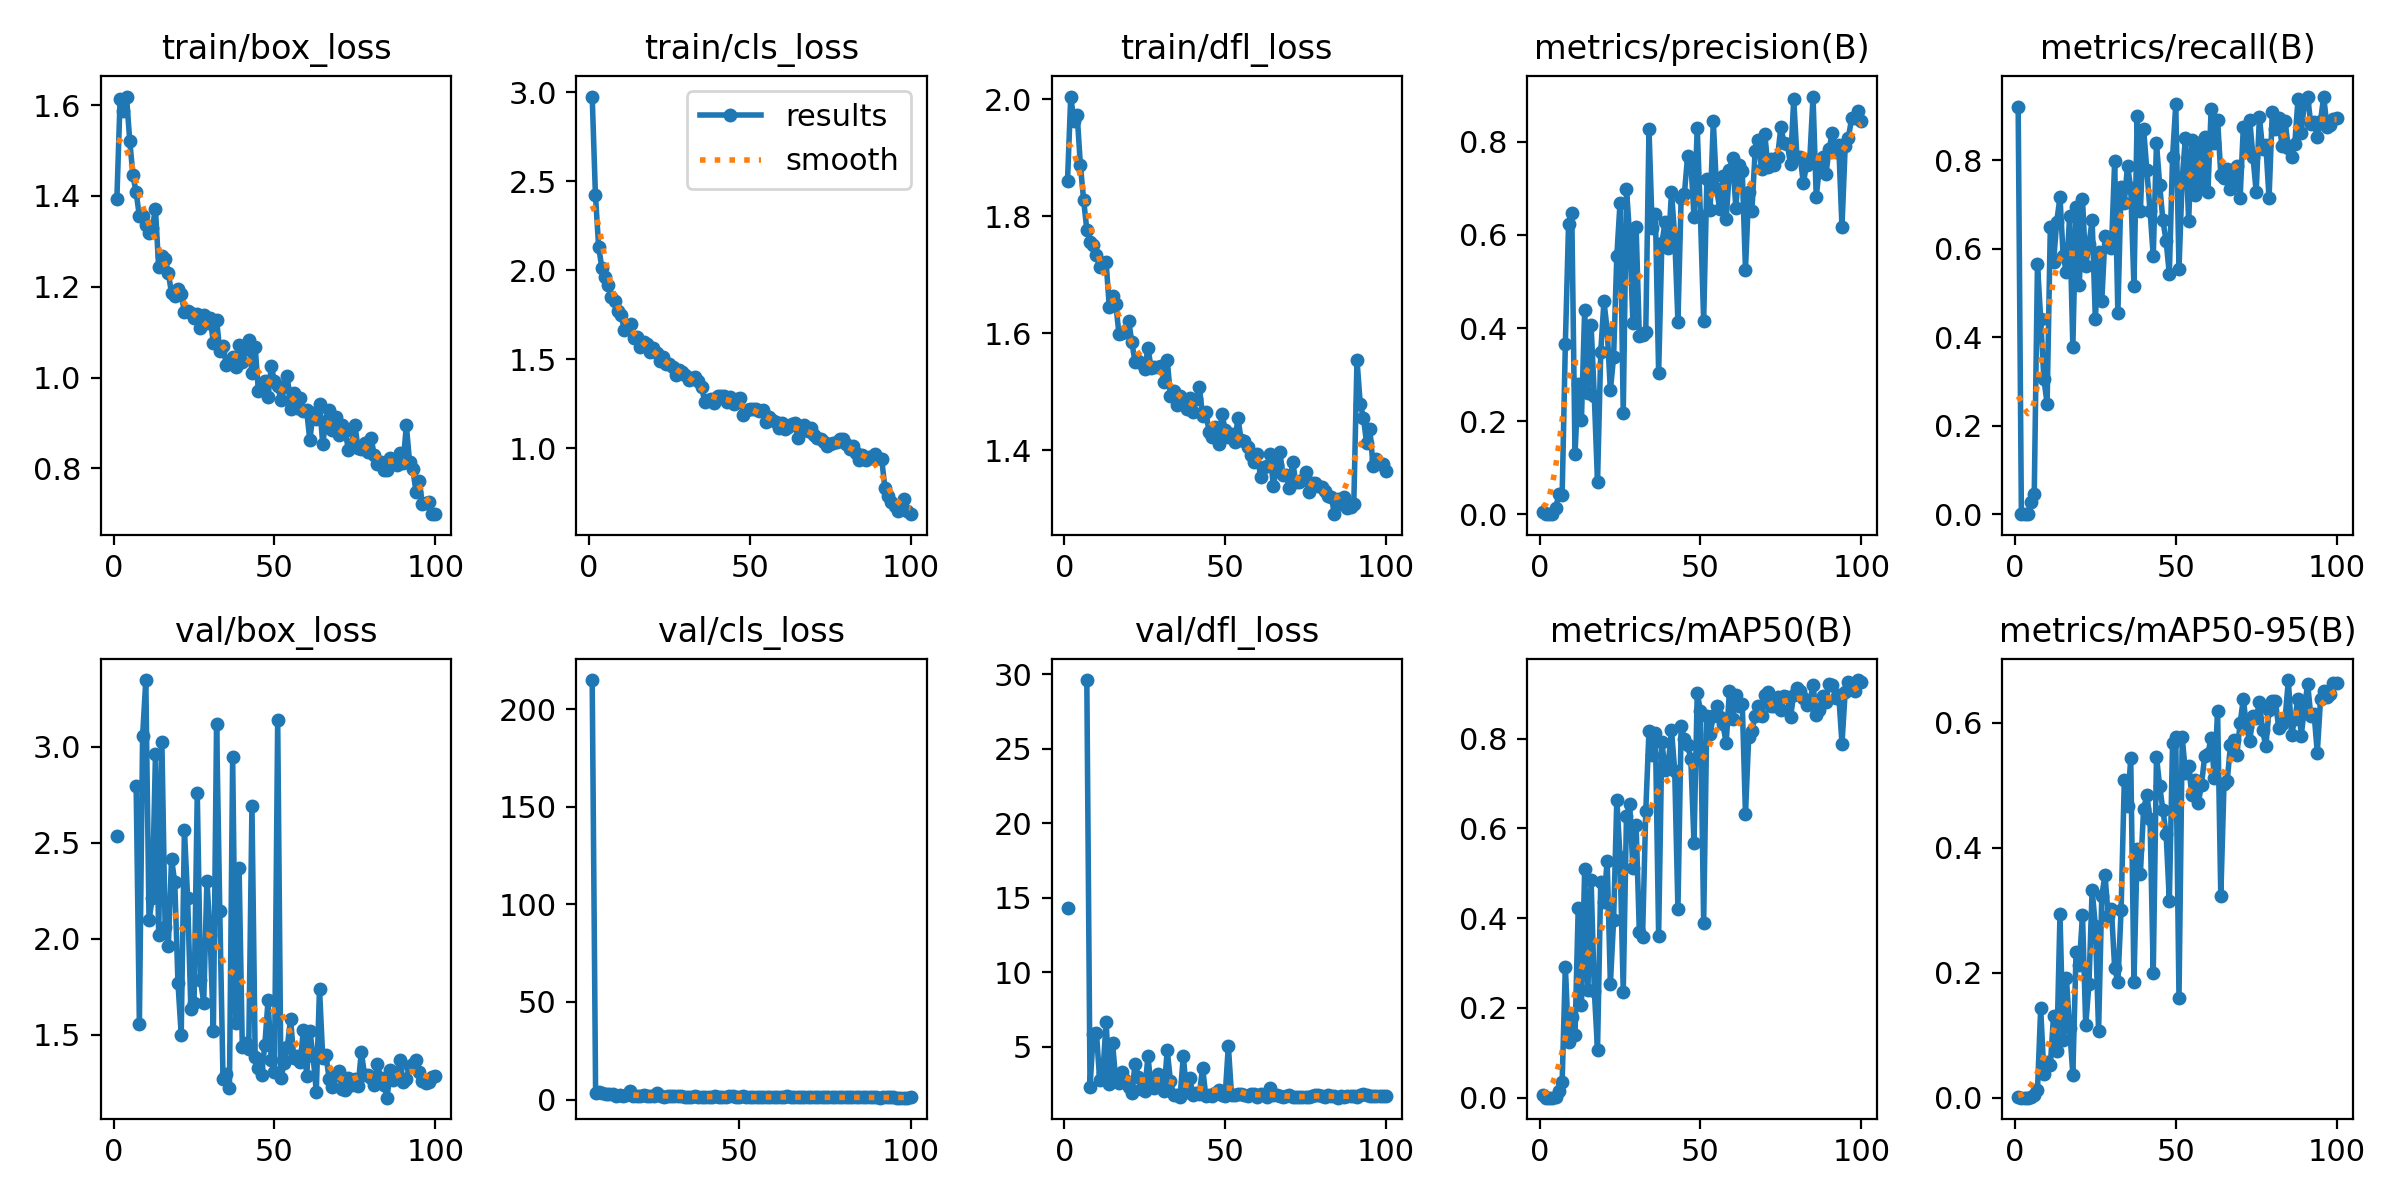


📊 Karmaşıklık Matrisi:


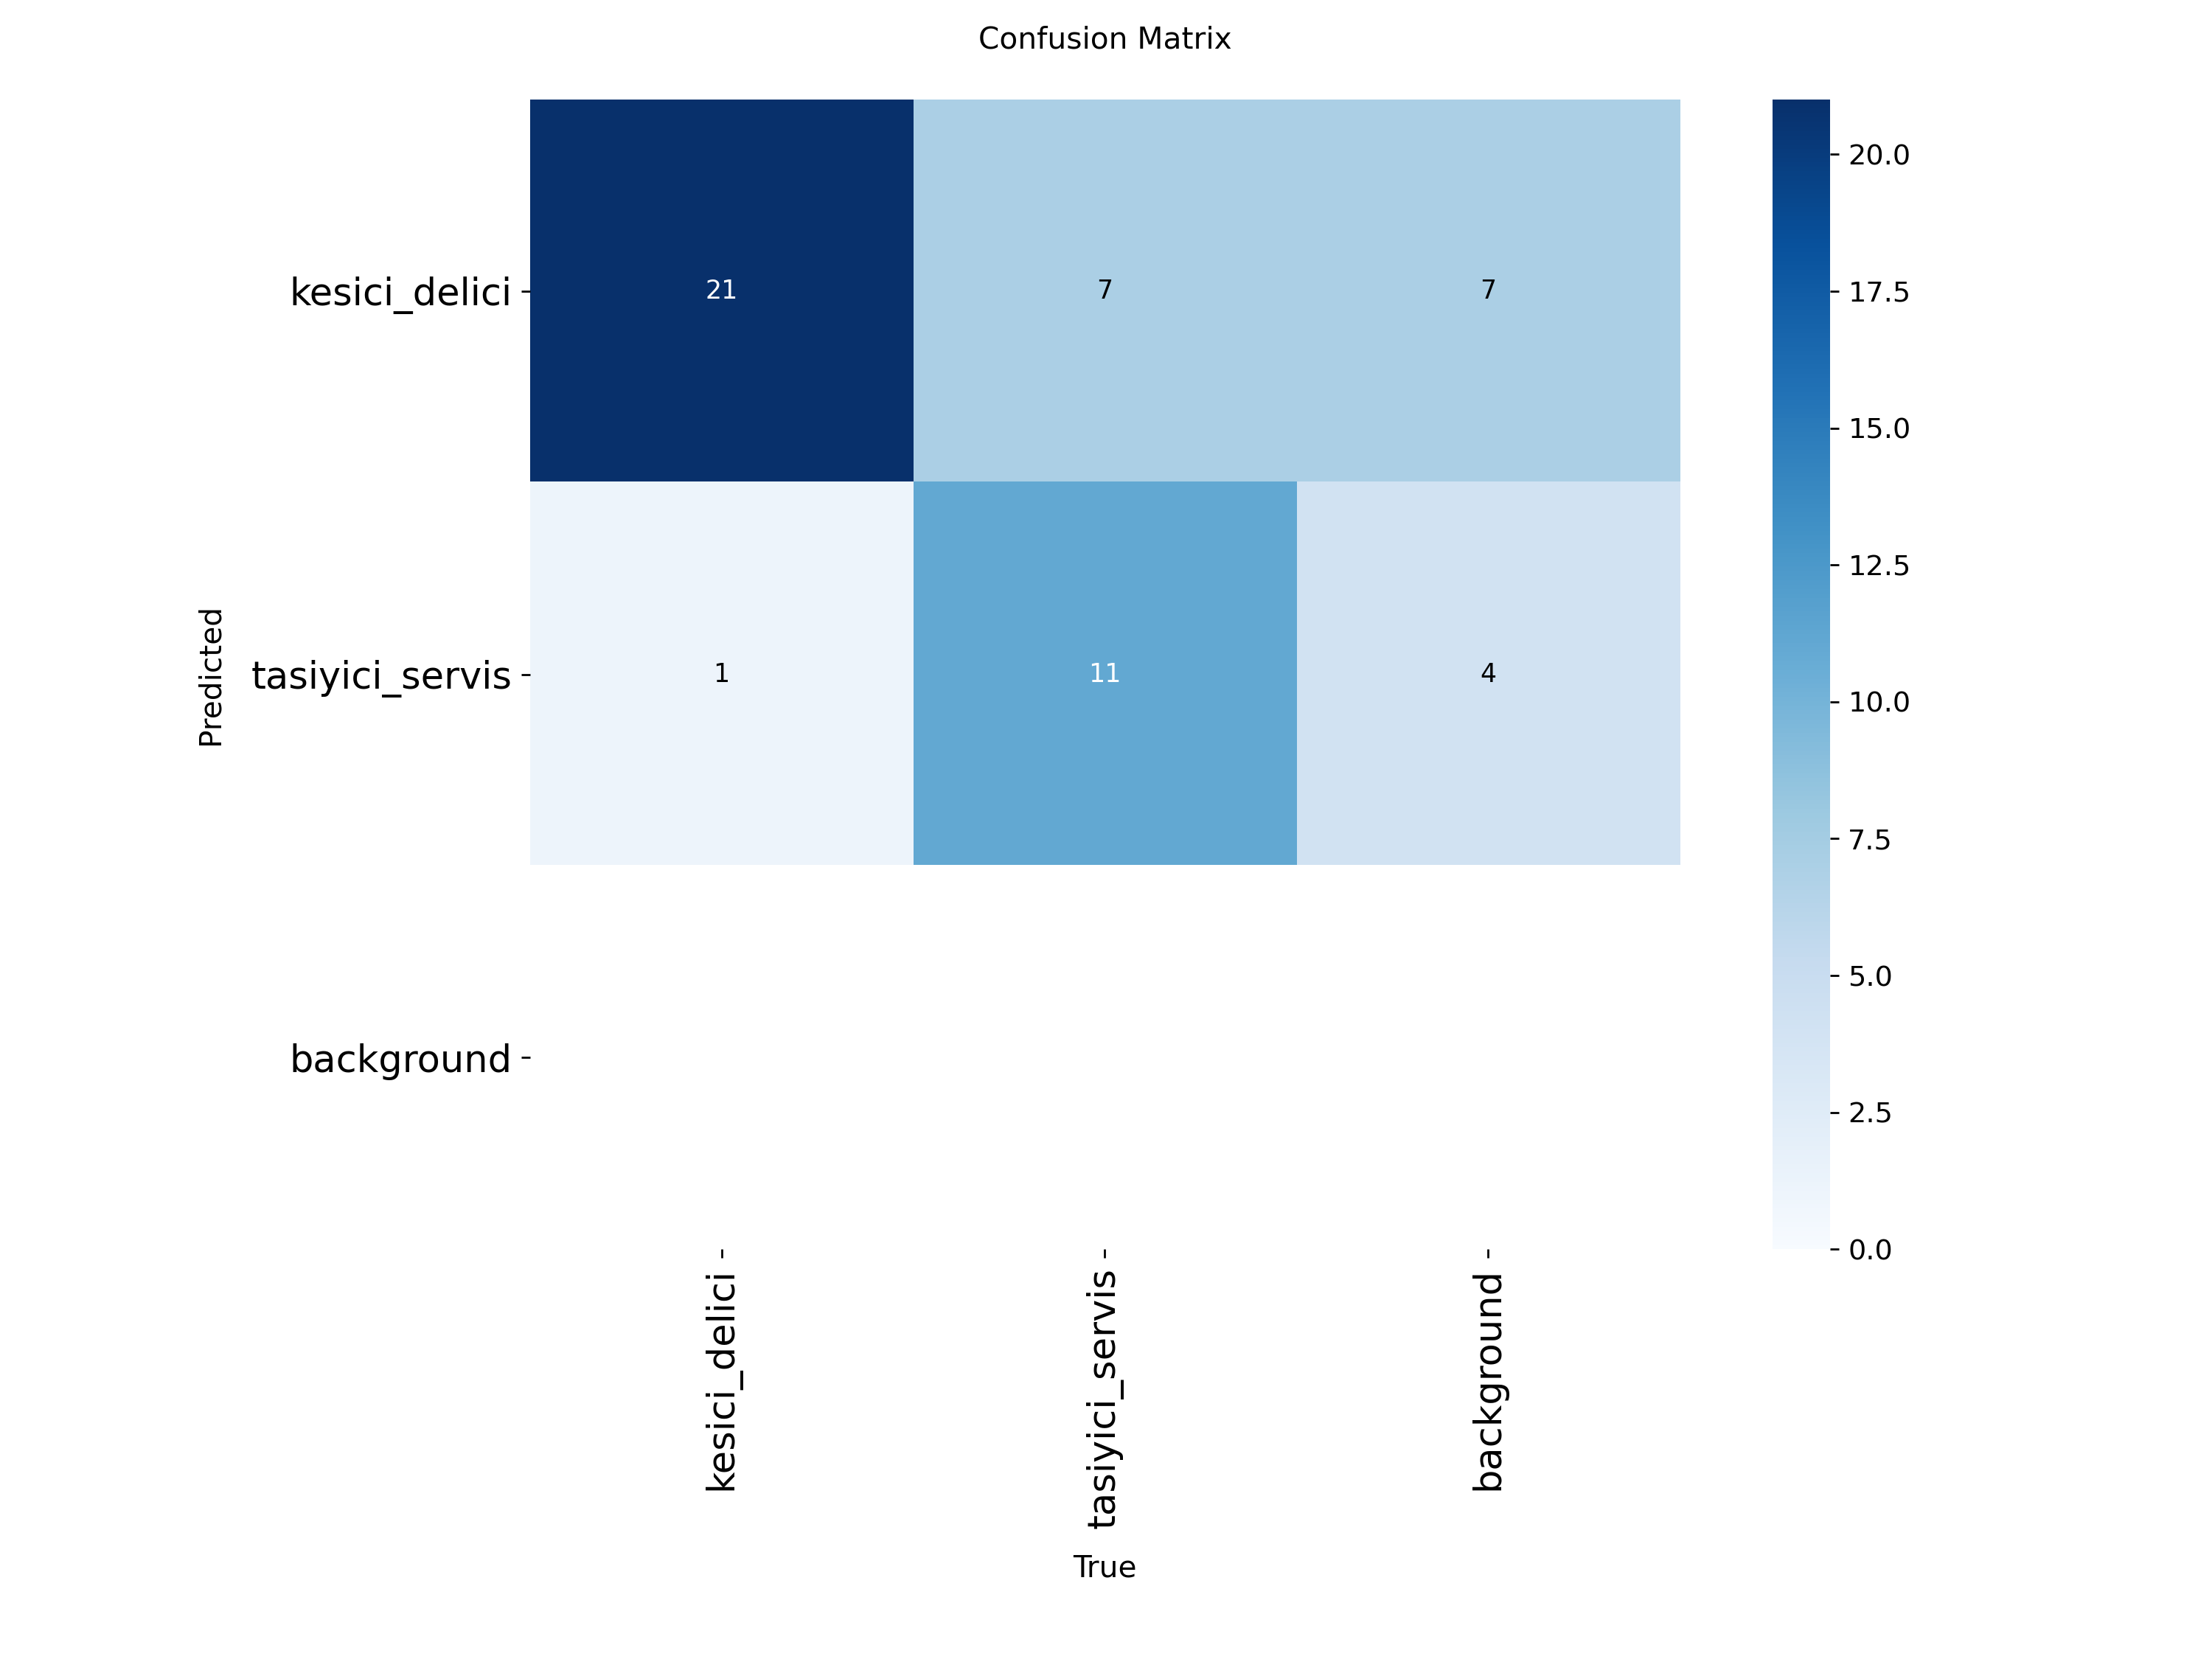

In [ ]:
# Eğitim sonuç grafiğini göster
from IPython.display import Image, display

# Eğitim sonuçları klasörü
results_dir = "/content/runs/detect/mutfak_esya_modeli2"  # Google Colab için
# Yerel ortam için: results_dir = "runs/detect/mutfak_esya_modeli"

results_image = os.path.join(results_dir, "results.png")
confusion_matrix = os.path.join(results_dir, "confusion_matrix.png")

# Eğitim metrikleri grafiği
if os.path.exists(results_image):
    print("📊 Eğitim Metrikleri Grafiği:")
    print("="*60)
    display(Image(filename=results_image, width=1000))
else:
    print(f"⚠️  Grafik bulunamadı: {results_image}")
    print("   Eğitim tamamlanmamış olabilir veya farklı bir konumda olabilir.")

# Karmaşıklık Matrisi
if os.path.exists(confusion_matrix):
    print("\n📊 Karmaşıklık Matrisi:")
    print("="*60)
    display(Image(filename=confusion_matrix, width=800))
else:
    print(f"\n⚠️  Karmaşıklık matrisi bulunamadı: {confusion_matrix}")


# Adım 5: Model Değerlendirme ve Başarı Metrikleri

Eğitilmiş modelin performansını değerlendirmek için validation seti üzerinde test yapılacaktır.

## Değerlendirme Metrikleri:

* **mAP50**: IoU threshold 0.5 için ortalama hassasiyet (en önemli metrik)
* **mAP50-95**: Farklı IoU threshold'ları için ortalama hassasiyet
* **Precision**: Doğru pozitif tahminlerin oranı
* **Recall**: Gerçek pozitiflerin ne kadarının bulunduğu
* **F1-Score**: Precision ve Recall'un harmonik ortalaması


In [ ]:
# En iyi model ağırlıklarını yükle ve detaylı doğruluk oranlarını göster
best_model_path = os.path.join(results_dir, "weights", "best.pt")

if os.path.exists(best_model_path):
    # Modeli yükle
    model = YOLO(best_model_path)
    print(f"✅ Model yüklendi: {best_model_path}")

    # Validation seti üzerinde değerlendirme yap
    print("\n" + "="*70)
    print("📊 EN İYİ MODEL AĞIRLIKLARI (best.pt) DOĞRULUK ORANLARI")
    print("="*70)

    # Validation metriklerini hesapla
    metrics = model.val(
        data=f"{dataset_path}/data.yaml",
        imgsz=640
    )

    # Genel Metrikler
    print("\n🎯 GENEL PERFORMANS METRİKLERİ:")
    print("-"*70)
    print(f"  • mAP50 (Ortalama Hassasiyet @ IoU=0.5):     {metrics.box.map50:.4f}  (%{metrics.box.map50*100:.2f})")
    print(f"  • mAP50-95 (Ortalama Hassasiyet @ IoU=0.5-0.95): {metrics.box.map:.4f}  (%{metrics.box.map*100:.2f})")
    print(f"  • Precision (Doğruluk):                      {metrics.box.mp:.4f}  (%{metrics.box.mp*100:.2f})")
    print(f"  • Recall (Geri Çağırma):                     {metrics.box.mr:.4f}  (%{metrics.box.mr*100:.2f})")

    # F1-Score hesapla
    f1_score = 2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr) if (metrics.box.mp + metrics.box.mr) > 0 else 0
    print(f"  • F1-Score (Harmonik Ortalama):              {f1_score:.4f}  (%{f1_score*100:.2f})")

    # Her sınıf için detaylı metrikler
    if hasattr(metrics, 'box') and hasattr(metrics.box, 'maps'):
        print("\n📋 SINIF BAZLI DOĞRULUK ORANLARI:")
        print("-"*70)

        # Sınıf isimlerini al
        class_names = list(model.names.values())
        maps_per_class = metrics.box.maps  # Her sınıf için mAP50-95 değerleri

        if len(maps_per_class) > 0:
            for i, (class_name, map_value) in enumerate(zip(class_names, maps_per_class)):
                print(f"  • {class_name:30s}: {map_value:.4f}  (%{map_value*100:.2f})")
        else:
            print("  ⚠️  Sınıf bazlı metrikler mevcut değil")

    # Precision ve Recall per class (eğer varsa)
    if hasattr(metrics, 'box') and hasattr(metrics.box, 'p'):
        precision_per_class = metrics.box.p  # Her sınıf için precision
        recall_per_class = metrics.box.r     # Her sınıf için recall

        if len(precision_per_class) > 0 and len(recall_per_class) > 0:
            print("\n📈 SINIF BAZLI PRECISION VE RECALL:")
            print("-"*70)
            for i, class_name in enumerate(class_names):
                if i < len(precision_per_class) and i < len(recall_per_class):
                    print(f"  • {class_name:30s}:")
                    print(f"      Precision: {precision_per_class[i]:.4f} (%{precision_per_class[i]*100:.2f})")
                    print(f"      Recall:    {recall_per_class[i]:.4f} (%{recall_per_class[i]*100:.2f})")

    # Performans Değerlendirmesi
    print("\n💡 PERFORMANS DEĞERLENDİRMESİ:")
    print("-"*70)
    if metrics.box.map50 >= 0.9:
        print("  ✅ Mükemmel! Model çok yüksek doğruluk oranına sahip.")
    elif metrics.box.map50 >= 0.8:
        print("  ✅ İyi! Model başarılı bir şekilde öğrenmiş.")
    elif metrics.box.map50 >= 0.7:
        print("  ⚠️  Orta seviye. Model iyileştirilebilir.")
    else:
        print("  ❌ Düşük performans. Model parametreleri veya eğitim gözden geçirilmeli.")

    print("\n" + "="*70)
    print("✅ Değerlendirme tamamlandı!")

else:
    print(f"⚠️  Model dosyası bulunamadı: {best_model_path}")
    print("   Lütfen eğitimin tamamlandığından emin olun.")
    print("   Eğitim sonrası dosya konumu: runs/detect/mutfak_esya_modeli/weights/best.pt")


✅ Model yüklendi: /content/runs/detect/mutfak_esya_modeli/weights/best.pt

📊 EN İYİ MODEL AĞIRLIKLARI (best.pt) DOĞRULUK ORANLARI
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 118.5±29.3 MB/s, size: 1.9 KB)
val: Scanning /content/mutfak-2/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 28.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.1it/s 1.4s
                   all         40         40          1      0.893      0.984      0.705
         kesici_delici         22         22          1      0.908      0.989      0.694
       tasiyici_servis         18         18          1      0.878      0.978      0.716
Speed: 8.1ms preprocess, 6.9ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /cont

# Adım 6: Test Görüntüsü Üzerinde Tahmin Yapma

Eğitilmiş modelin gerçek bir görüntü üzerinde nasıl çalıştığını test edelim.


📷 Test görüntüsü: /content/mutfak-2/valid/images/img_002_jpg.rf.0a221c0389b3c0e24af1ba6785dc99cf.jpg

image 1/1 /content/mutfak-2/valid/images/img_002_jpg.rf.0a221c0389b3c0e24af1ba6785dc99cf.jpg: 640x640 1 kesici_delici, 7.3ms
Speed: 2.2ms preprocess, 7.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2

✅ Tahmin sonucu kaydedildi: /content/runs/detect/predict2/img_002_jpg.rf.0a221c0389b3c0e24af1ba6785dc99cf.jpg


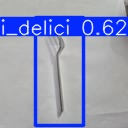


🔍 Tespit Edilen Nesneler:
1. kesici_delici: 62.10% güven


In [ ]:
# Test görüntüsü üzerinde tahmin yap
# Validation setinden rastgele bir görüntü seç veya kendi görüntünü kullan

# Validation klasöründen bir görüntü bul
val_images_dir = os.path.join(dataset_path, "valid", "images")
if os.path.exists(val_images_dir):
    import random
    val_images = [f for f in os.listdir(val_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if val_images:
        # Rastgele bir görüntü seç
        test_image = os.path.join(val_images_dir, random.choice(val_images))
        print(f"📷 Test görüntüsü: {test_image}")

        # Tahmin yap
        results = model.predict(
            source=test_image,
            imgsz=640,
            conf=0.25,  # Confidence threshold (güven eşiği)
            save=True,  # Sonuçları kaydet
            show_labels=True,  # Etiketleri göster
            show_conf=True  # Confidence skorlarını göster
        )

        # Sonuç görüntüsünü göster
        result_image_path = results[0].save_dir + "/" + os.path.basename(test_image)
        if os.path.exists(result_image_path):
            print(f"\n✅ Tahmin sonucu kaydedildi: {result_image_path}")
            display(Image(filename=result_image_path, width=800))

        # Tespit edilen nesneleri yazdır
        print(f"\n🔍 Tespit Edilen Nesneler:")
        print("="*60)
        for i, box in enumerate(results[0].boxes):
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = model.names[cls]
            print(f"{i+1}. {class_name}: {conf:.2%} güven")
    else:
        print("⚠️  Validation klasöründe görüntü bulunamadı.")
else:
    print("⚠️  Validation klasörü bulunamadı.")


# Adım 7: Model Dosyasının Kaydedilmesi ve İndirilmesi

Eğitilmiş model ağırlıkları (`best.pt`)



In [ ]:
# best.pt dosyasının konumunu kontrol et ve kopyala
import shutil

best_model_path = os.path.join(results_dir, "weights", "best.pt")
project_root = Path.cwd()  # Proje kök dizini

if os.path.exists(best_model_path):
    # best.pt dosyasını proje kök dizinine kopyala
    destination = os.path.join(project_root, "best.pt")
    shutil.copy2(best_model_path, destination)
    print(f"✅ best.pt dosyası kopyalandı: {destination}")
    print(f"   Dosya boyutu: {os.path.getsize(destination) / (1024*1024):.2f} MB")

    # Google Colab kullanıyorsanız dosyayı indirmek için:
    # from google.colab import files
    # files.download('best.pt')
else:
    print(f"⚠️  best.pt dosyası bulunamadı: {best_model_path}")


✅ best.pt dosyası kopyalandı: /content/best.pt
   Dosya boyutu: 5.97 MB


## Adım 8: Modeli ONNX Formatına Dönüştürme

Bu bölümde, eğitilmiş YOLOv8 modelini (best.pt) ONNX formatına dönüştüreceğiz. ONNX (Open Neural Network Exchange), farklı derin öğrenme frameworkleri arasında modellerin taşınabilirliğini sağlayan açık bir standarttır.

### Neden ONNX?

*   **Framework Bağımsızlığı**: PyTorch (YOLOv8'in arkasındaki framework) dışında, TensorFlow, Keras, Caffe2 gibi diğer framework de modelin kullanılabilmesini sağlar.
*   **Performans Optimizasyonu**: ONNX Runtime gibi araçlarla modelin daha hızlı çalışmasını sağlayabilir.
*   **Dağıtım Kolaylığı**: Mobil cihazlar, web tabanlı uygulamalar veya gömülü sistemler gibi çeşitli platformlarda dağıtım için idealdir.

In [ ]:
# Modeli ONNX formatına dönüştür
print("🚀 Modeli ONNX formatına dönüştürülüyor...")
model.export(format='onnx')

# Oluşan ONNX dosyasının yolunu kontrol et
onnx_model_path = os.path.join(results_dir, "weights", "best.onnx")
if os.path.exists(onnx_model_path):
    print(f"✅ Model başarıyla ONNX formatına dönüştürüldü: {onnx_model_path}")
    print(f"   Dosya boyutu: {os.path.getsize(onnx_model_path) / (1024*1024):.2f} MB")
else:
    print(f"⚠️  ONNX model dosyası bulunamadı. Dönüşüm başarısız olmuş olabilir.")

🚀 Modeli ONNX formatına dönüştürülüyor...
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 112 layers, 43,608,150 parameters, 0 gradients, 164.8 GFLOPs

PyTorch: starting from '/content/runs/detect/mutfak_esya_modeli2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (83.6 MB)

ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.79...
ONNX: export success ✅ 14.7s, saved as '/content/runs/detect/mutfak_esya_modeli2/weights/best.onnx' (166.6 MB)

Export complete (19.2s)
Results saved to /content/runs/detect/mutfak_esya_modeli2/weights
Predict:         yolo predict task=detect model=/content/runs/detect/mutfak_esya_modeli2/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/runs/detect/mutfak_esya_modeli2/weights/best.onnx imgsz=640 data=/content/mutfak-2/data.yaml  
Visualize:       https://netron.app
✅ Model başarıyla ONNX form

# Adım 9: Sonuçlar ve Özet

## Proje Tamamlandı! ✅

Bu projede aşağıdaki adımlar başarıyla tamamlanmıştır:

### 1. Veri Seti Hazırlığı ✅
- Roboflow platformundan mutfak eşyaları veri seti indirildi
- YOLOv8 uyumlu format (txt etiketleri) kullanıldı
- En az 2 sınıf ve 200+ etiketli görsel içeren veri seti hazırlandı

### 2. YOLOv8 Model Eğitimi ✅
- YOLOv8l (large) modeli kullanıldı
- 100 epoch eğitim yapıldı
- En iyi model ağırlıkları `best.pt` olarak kaydedildi

### 3. Model Değerlendirme ✅
- mAP50, mAP50-95 metrikleri hesaplandı
- Precision, Recall, F1-Score değerleri raporlandı
- Eğitim grafikleri ve karmaşıklık matrisi oluşturuldu
## Önemli Notlar:

1. **best.pt dosyası**: Model eğitimi tamamlandıktan sonra `runs/detect/mutfak_esya_modeli/weights/best.pt` konumunda bulunur

